# Introduction

## The skyrmion

In [101]:
import numpy as np
import matplotlib.pyplot as plt

def skyrmion_ansatz(b, nx, ny):
    """
    generates a config with Q=1 via a stereographic projection of id: S^2 -> s^2;
    b is the size of the 'skyrmion'
    """
    X, Y = np.zeros((nx,ny)), np.zeros((nx,ny))
    for i in range(nx):
        for j in range(ny):
            X[i,j] = i
            Y[i,j] = j
        #end
    #end

    #shift the centre
    X -= (nx-1)//2+0.5
    Y -= (ny-1)//2+0.5
    #rescale
    X *= 1/b; Y *= 1/b
    #compute the projection
    n = np.zeros((3, nx, ny))
    n[0,:,:] = 2*X/(1+X**2+Y**2)
    n[1,:,:] = 2*Y/(1+X**2+Y**2)
    n[2,:,:] = (X**2+Y**2-1)/(X**2+Y**2+1)
    return n
#end
    

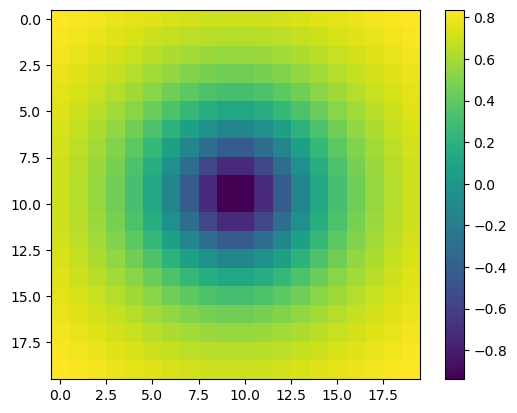

In [104]:
n = skyrmion_ansatz(4.0, 20,20)
plt.imshow(n[2,:,:])
plt.colorbar()

[-2.  -1.8 -1.6 -1.4 -1.2 -1.  -0.8 -0.6 -0.4 -0.2  0.   0.2  0.4  0.6
  0.8  1.   1.2  1.4  1.6  1.8]


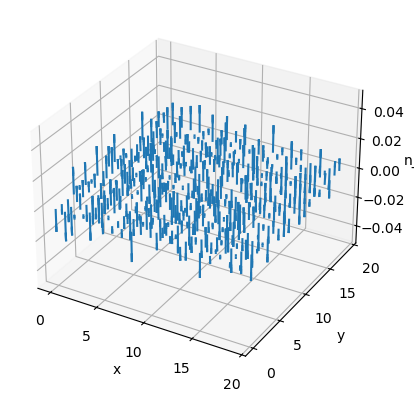

In [83]:
n = skyrmion_ansatz(5.0, 20,20)
import numpy as np
import matplotlib.pyplot as plt

# Example data
nx, ny = 20, 20
n = np.random.randn(3, nx, ny)
n /= np.linalg.norm(n, axis=0)  # normalize spins

# lattice coordinates
x = np.arange(nx)
y = np.arange(ny)
X, Y = np.meshgrid(x, y, indexing="ij")
Z = np.zeros_like(X)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.quiver(
    X, Y, Z,
    n[0], n[1], n[2],
    length=0.02,
    normalize=True
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("n_z")

plt.show()

In [46]:
n = 4
(n-1)//2

1

## Sterographic projection and the Hamiltonian

$$
n_x = \frac{w + \bar{w}}{1+\bar{w}w} \qquad n_y = -i \frac{w - \bar{w}}{1+\bar{w}w} \qquad n_z = \frac{1-\bar{w}w}{1+\bar{w}w} 
$$

The inverse mapping is

$$
|w|^2 = \frac{1-n_z}{1+n_z} \qquad w = \frac{n_x + i n_y}{1+n_z}
$$

In [3]:
import numpy as np

def w_project(n):
    w = np.array(complex, n.shape[1], n.shape[2])
    w = (n[0,:,:]+ 1j*n[1,:,:]) / (1+n[2,:,:])
    return w
#end

def n_vector(w):
    n = np.array(float, 3, w.shape[0], w.shape[1])
    n[0,:,:] = np.real( (w + np.conj(w)) / (1 + np.conj(w)*w) )
    n[1,:,:] = np.real(-1j * (w - np.conj(w)) / (1 + np.conj(w)*w))
    n[2,:,:] = np.real((1-w*np.conj(w)) / (1 + np.conj(w)*w))
    return n
#end